# Flight Delay Predictor
**Project Goal:** Predict flight delays by combining airline logs with historical weather data using Logistic Regression.
**Evaluation Metrics:** Accuracy, Precision, Recall.
**Key Techniques:** Data merging, date/time feature engineering, and interactive UI.

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Set visualization style
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')


from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

## 2. Loading the Dataset
We load the dataset `flight_delay (1).csv` into a Pandas DataFrame and display the first few rows to understand its structure.

In [70]:
# Load the dataset
df = pd.read_csv('flight_delay (1).csv')

# Display the first 5 rows
display(df.head())

# Check the shape of the dataset
print(f"Dataset Shape: {df.shape}")

,departure_hour,scheduled_duration_min,distance_miles,num_connections,wind_speed_kmh,visibility_km,prev_flight_delay_min,is_delayed
0,23.0,61.0,2303.0,1.0,67.6,13.8,79.0,0
1,20.0,75.0,338.0,2.0,71.5,1.4,89.0,1
2,20.0,167.0,1257.0,0.0,62.1,7.5,13.0,0
3,11.0,87.0,1274.0,2.0,12.4,9.1,64.0,0
4,5.0,56.0,2567.0,2.0,73.7,7.5,19.0,0


Dataset Shape: (694, 8)


## 3. Exploratory Data Analysis (EDA) and Cleaning
Before modeling, we need to understand our data types, check for missing values, and visualize the distribution of our target variable (delayed flights).

In [71]:
# Display dataset info and data types
print("--- Dataset Information ---")
df.info()

# Check for missing values
print("\n--- Missing Values ---")
print(df.isnull().sum())

# Drop rows with missing values (or you can fill them using df.fillna())
df.dropna(inplace=True)
print(f"\nShape after dropping missing values: {df.shape}")

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 694 entries, 0 to 693
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   departure_hour          694 non-null    float64
 1   scheduled_duration_min  694 non-null    float64
 2   distance_miles          694 non-null    float64
 3   num_connections         694 non-null    float64
 4   wind_speed_kmh          673 non-null    object 
 5   visibility_km           674 non-null    float64
 6   prev_flight_delay_min   694 non-null    float64
 7   is_delayed              694 non-null    int64  
dtypes: float64(6), int64(1), object(1)
memory usage: 43.5+ KB

--- Missing Values ---
departure_hour             0
scheduled_duration_min     0
distance_miles             0
num_connections            0
wind_speed_kmh            21
visibility_km             20
prev_flight_delay_min      0
is_delayed                 0
dtype: int64

Shape

### 3.1 Visualizing the Target Variable
Let's see the balance of our target variable to understand how many flights were delayed versus on time. *(Note: Adjust the column name 'Delay' in the code below to match your dataset's exact target column name).*

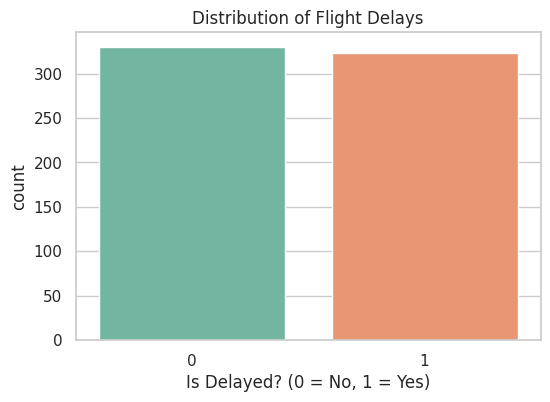

In [72]:


# Define the exact target column name from the dataset
target_col = 'is_delayed'

# Plot the distribution of delays
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=target_col, palette='Set2')
plt.title('Distribution of Flight Delays')
plt.xlabel('Is Delayed? (0 = No, 1 = Yes)')
plt.show()

In [73]:
# 1. Clean the 'wind_speed_kmh' column which contains text like '77.8_err'
df['wind_speed_kmh'] = df['wind_speed_kmh'].astype(str).str.replace('_err', '')
df['wind_speed_kmh'] = pd.to_numeric(df['wind_speed_kmh'], errors='coerce')

# 2. Handle any missing values by filling them with the column median
df = df.fillna(df.median())

display(df.head())
print("\nData Types after cleaning:\n", df.dtypes)

,departure_hour,scheduled_duration_min,distance_miles,num_connections,wind_speed_kmh,visibility_km,prev_flight_delay_min,is_delayed
0,23.0,61.0,2303.0,1.0,67.6,13.8,79.0,0
1,20.0,75.0,338.0,2.0,71.5,1.4,89.0,1
2,20.0,167.0,1257.0,0.0,62.1,7.5,13.0,0
3,11.0,87.0,1274.0,2.0,12.4,9.1,64.0,0
4,5.0,56.0,2567.0,2.0,73.7,7.5,19.0,0



Data Types after cleaning:
 departure_hour            float64
scheduled_duration_min    float64
distance_miles            float64
num_connections           float64
wind_speed_kmh            float64
visibility_km             float64
prev_flight_delay_min     float64
is_delayed                  int64
dtype: object


In [74]:
# Define features (X) and target (y)
target_col = 'is_delayed'
X = df.drop(columns=[target_col])
y = df[target_col]

# Split the dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale the numeric features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training shape: {X_train_scaled.shape}")
print(f"Testing shape: {X_test_scaled.shape}")

Training shape: (522, 7)
Testing shape: (131, 7)


In [75]:
model = make_pipeline(
    StandardScaler(),
    LogisticRegression(random_state=42)
)
model.fit(X_train_scaled, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression', LogisticRegression(random_state=42))])

In [78]:
model.score(X_test, y_test)

0.4961832061068702

In [76]:
import ipywidgets as widgets

# Create interactive widgets matching the actual dataset features
dep_hour_widget = widgets.FloatSlider(min=0, max=23, step=1, description='Dep. Hour:', value=12)
duration_widget = widgets.FloatText(description='Duration (m):', value=120.0)
distance_widget = widgets.FloatText(description='Dist (miles):', value=500.0)
connections_widget = widgets.IntSlider(min=0, max=5, step=1, description='Connections:', value=0)
wind_widget = widgets.FloatSlider(min=0, max=150, step=0.1, description='Wind (km/h):', value=15.0)
visibility_widget = widgets.FloatSlider(min=0, max=20, step=0.1, description='Visib (km):', value=10.0)
prev_delay_widget = widgets.FloatText(description='Prev Delay:', value=0.0)

# Create a button for prediction
predict_btn = widgets.Button(description="Predict Delay", button_style='success')
output = widgets.Output()

def on_predict_click(b):
    with output:
        output.clear_output()

        # Gather inputs into a dataframe with exact column names as X_train
        input_data = pd.DataFrame({
            'departure_hour': [dep_hour_widget.value],
            'scheduled_duration_min': [duration_widget.value],
            'distance_miles': [distance_widget.value],
            'num_connections': [connections_widget.value],
            'wind_speed_kmh': [wind_widget.value],
            'visibility_km': [visibility_widget.value],
            'prev_flight_delay_min': [prev_delay_widget.value]
        })

        # Scale the input data
        input_scaled = scaler.transform(input_data)

        # Predict
        prediction = model.predict(input_scaled)[0]
        prob = model.predict_proba(input_scaled)[0][1]

        # Display Result
        if prediction == 1:
            print(f"⚠️ Flight is predicted to be DELAYED (Probability: {prob:.2%})")
        else:
            print(f"✅ Flight is predicted to be ON TIME (Probability of delay: {prob:.2%})")

predict_btn.on_click(on_predict_click)

# Display the UI
ui = widgets.VBox([
    dep_hour_widget, duration_widget, distance_widget,
    connections_widget, wind_widget, visibility_widget,
    prev_delay_widget, predict_btn, output
])
display(ui)